# Question Parser — Step-by-step Visualization

How `QuestionParser.parse()` turns a raw question into a structured `Query(type, target, constraints)`.

**Pipeline:** `raw question → negation check → template match → target extraction → Query`

In [6]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

from src.question.parser import QuestionParser, NEGATION_CUES

VINDR_VOCAB = {
    "Aortic enlargement", "Atelectasis", "Calcification", "Cardiomegaly",
    "Consolidation", "ILD", "Infiltration", "Lung Opacity", "Nodule/Mass",
    "Other lesion", "Pleural effusion", "Pleural thickening", "Pneumothorax",
    "Pulmonary fibrosis",
}

parser = QuestionParser(finding_vocab=VINDR_VOCAB)
print(f"Parser initialized with {len(VINDR_VOCAB)} findings")

Parser initialized with 14 findings


## 1. Trace a single question through each step

Walk through `parse()` step by step, showing what happens at each decision point.

In [7]:
def trace_parse(question):
    """Show each decision step of the parser."""
    q = question.lower()
    target = parser._find_target(question)

    print(f"Input:    \"{question}\"")
    print(f"Lowered:  \"{q}\"")
    print(f"Target:   {target}")
    print()

    # Step 1: negation check (always first — safety-critical)
    neg_match = NEGATION_CUES.search(question)
    if neg_match:
        result = f'YES: "{neg_match.group()}"'
    else:
        result = "no"

    print(f"Step 1 — Negation cues? {result}")
    if neg_match:
        print(f"  -> type = negation (stop here, safety-critical)")
        print(f"\nResult: {parser.parse(question)}")
        return

    # Step 2-6: template matching
    rules = [
        ("how many",                              "counting",    None,   {}),
        ("where is",                              "relational",  target, {"attr": "location"}),
        ("which side",                            "relational",  None,   {"attr": "laterality"}),
        ("what abnormality / what finding",        "existential", None,   {"scope": "open"}),
        ("is there / does...show",                "existential", target, {}),
    ]

    checks = [
        "how many" in q,
        "where is" in q,
        "which side" in q,
        "what abnormality" in q or "what finding" in q,
        "is there" in q or ("does" in q and "show" in q),
    ]

    matched = False
    for i, (name, qtype, tgt, cons) in enumerate(rules):
        hit = checks[i]
        step = i + 2
        status = "YES" if hit else "no"
        print(f"Step {step} — \"{name}\"?  {status}")
        if hit and not matched:
            print(f"  -> type = {qtype}, target = {tgt}, constraints = {cons}")
            matched = True
            break

    if not matched:
        print(f"Step 7 — No rule matched -> conservative default: type = relational")

    print(f"\nResult: {parser.parse(question)}")


trace_parse("Does this X-ray show Cardiomegaly?")

Input:    "Does this X-ray show Cardiomegaly?"
Lowered:  "does this x-ray show cardiomegaly?"
Target:   Cardiomegaly

Step 1 — Negation cues? no
Step 2 — "how many"?  no
Step 3 — "where is"?  no
Step 4 — "which side"?  no
Step 5 — "what abnormality / what finding"?  no
Step 6 — "is there / does...show"?  YES
  -> type = existential, target = Cardiomegaly, constraints = {}

Result: type='existential' target='Cardiomegaly' constraints={} raw_question='Does this X-ray show Cardiomegaly?' parse_confidence=1.0 parser_tier='rule'


## 2. Trace all 6 VinDr templates + negation + unknown

In [8]:
examples = [
    "Does this X-ray show Cardiomegaly?",       # Is_there  -> existential
    "Is there Pleural effusion?",                # Yes_No    -> existential
    "Where is the Nodule/Mass?",                 # Where     -> relational
    "Which side shows the abnormality?",         # Which     -> relational
    "What abnormality is visible?",              # What      -> existential (open)
    "How many findings are there?",              # How_many  -> counting
    "Is there no Cardiomegaly?",                 # negation  -> negation
    "Explain the cardiac shadow",                # unknown   -> relational (default)
]

for q in examples:
    trace_parse(q)
    print("=" * 60)
    print()

Input:    "Does this X-ray show Cardiomegaly?"
Lowered:  "does this x-ray show cardiomegaly?"
Target:   Cardiomegaly

Step 1 — Negation cues? no
Step 2 — "how many"?  no
Step 3 — "where is"?  no
Step 4 — "which side"?  no
Step 5 — "what abnormality / what finding"?  no
Step 6 — "is there / does...show"?  YES
  -> type = existential, target = Cardiomegaly, constraints = {}

Result: type='existential' target='Cardiomegaly' constraints={} raw_question='Does this X-ray show Cardiomegaly?' parse_confidence=1.0 parser_tier='rule'

Input:    "Is there Pleural effusion?"
Lowered:  "is there pleural effusion?"
Target:   Pleural effusion

Step 1 — Negation cues? no
Step 2 — "how many"?  no
Step 3 — "where is"?  no
Step 4 — "which side"?  no
Step 5 — "what abnormality / what finding"?  no
Step 6 — "is there / does...show"?  YES
  -> type = existential, target = Pleural effusion, constraints = {}

Result: type='existential' target='Pleural effusion' constraints={} raw_question='Is there Pleural ef

## 3. VinDr gold-label validation — type distribution & accuracy

In [9]:
import json
import matplotlib.pyplot as plt

with open("../../data/vindr_cxr_vqa/vqa.json") as f:
    data = json.load(f)

# Map gold types -> QType
GOLD_TO_QTYPE = {
    "Is_there": "existential", "Yes_No": "existential",
    "Where": "relational", "Which": "relational",
    "What": "existential", "How_many": "counting",
}

# Parse all questions
results = []
for img in data:
    for item in img["vqa"]:
        q = parser.parse(item["question"])
        results.append({
            "gold_type": item["type"],
            "expected": GOLD_TO_QTYPE[item["type"]],
            "parsed": q.type,
            "correct": q.type == GOLD_TO_QTYPE[item["type"]],
        })

total = len(results)
correct = sum(r["correct"] for r in results)
print(f"Total questions: {total}")
print(f"Type accuracy:   {correct}/{total} = {correct/total*100:.1f}%")

Total questions: 17597
Type accuracy:   17597/17597 = 100.0%


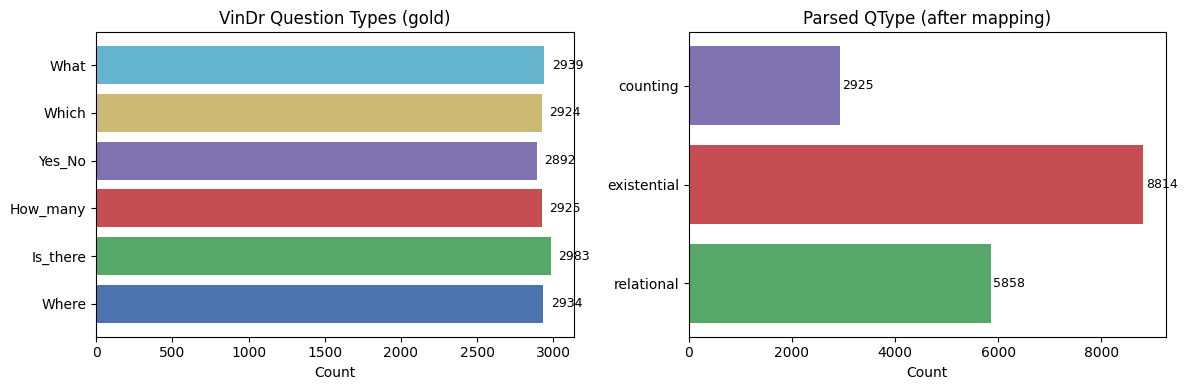

In [10]:
# --- Chart 1: Gold type distribution (VinDr) ---
from collections import Counter

gold_counts = Counter(r["gold_type"] for r in results)
labels = list(gold_counts.keys())
counts = list(gold_counts.values())
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(labels, counts, color=colors[:len(labels)])
axes[0].set_xlabel("Count")
axes[0].set_title("VinDr Question Types (gold)")
for i, c in enumerate(counts):
    axes[0].text(c + 50, i, str(c), va="center", fontsize=9)

# --- Chart 2: Parsed QType distribution ---
parsed_counts = Counter(r["parsed"] for r in results)
p_labels = list(parsed_counts.keys())
p_counts = list(parsed_counts.values())

axes[1].barh(p_labels, p_counts, color=["#55A868", "#C44E52", "#8172B2"])
axes[1].set_xlabel("Count")
axes[1].set_title("Parsed QType (after mapping)")
for i, c in enumerate(p_counts):
    axes[1].text(c + 50, i, str(c), va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 4. Per-type accuracy & mapping flow

Shows how 6 VinDr gold types collapse into 3 QTypes (no negation in VinDr data).

In [11]:
# Per gold-type accuracy
by_type = {}
for r in results:
    gt = r["gold_type"]
    if gt not in by_type:
        by_type[gt] = {"correct": 0, "total": 0}
    by_type[gt]["total"] += 1
    if r["correct"]:
        by_type[gt]["correct"] += 1

print(f"{'Gold Type':12s} {'QType':12s} {'Correct':>8s} {'Total':>8s} {'Accuracy':>10s}")
print("-" * 54)
for gt in sorted(by_type):
    c = by_type[gt]
    acc = c["correct"] / c["total"] * 100
    print(f"{gt:12s} {GOLD_TO_QTYPE[gt]:12s} {c['correct']:8d} {c['total']:8d} {acc:9.1f}%")

# Mapping diagram
print()
print("Mapping flow:")
print("  Is_there  ─┐")
print("  Yes_No    ─┤── existential  (engine: early-exit OK)")
print("  What      ─┘")
print("  Where     ─┐")
print("  Which     ─┘── relational   (engine: budget traversal)")
print("  How_many  ──── counting     (engine: UNVERIFIABLE, abstain)")
print()
print("  (negation cues) ── negation (engine: closed-world enumeration)")
print("  (no match)      ── relational (conservative default, NEVER existential)")

Gold Type    QType         Correct    Total   Accuracy
------------------------------------------------------
How_many     counting         2925     2925     100.0%
Is_there     existential      2983     2983     100.0%
What         existential      2939     2939     100.0%
Where        relational       2934     2934     100.0%
Which        relational       2924     2924     100.0%
Yes_No       existential      2892     2892     100.0%

Mapping flow:
  Is_there  ─┐
  Yes_No    ─┤── existential  (engine: early-exit OK)
  What      ─┘
  Where     ─┐
  Which     ─┘── relational   (engine: budget traversal)
  How_many  ──── counting     (engine: UNVERIFIABLE, abstain)

  (negation cues) ── negation (engine: closed-world enumeration)
  (no match)      ── relational (conservative default, NEVER existential)


## 5. Target extraction accuracy (per finding)

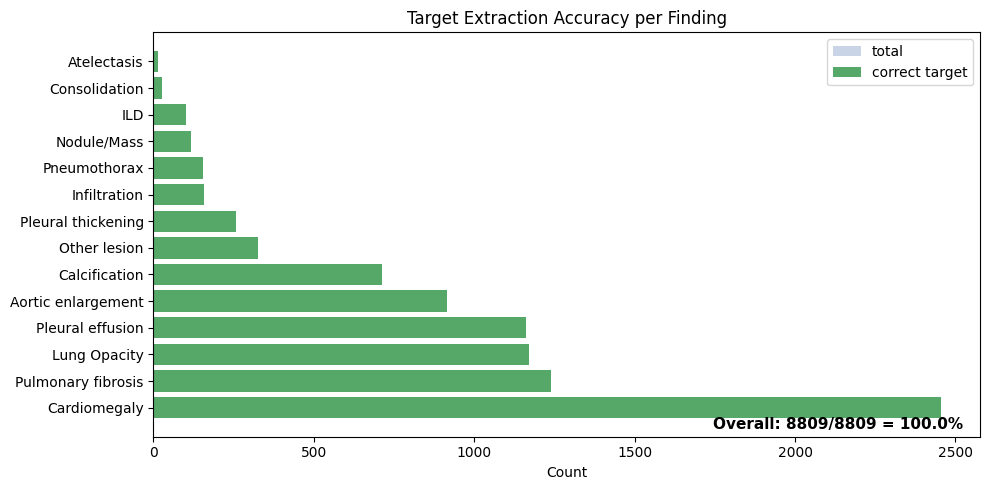

In [12]:
# Target accuracy: only for types where finding appears in the question
target_results = []
for img in data:
    for item in img["vqa"]:
        if item["type"] in ("Is_there", "Yes_No", "Where"):
            q = parser.parse(item["question"])
            target_results.append({
                "gt_finding": item["gt_finding"],
                "parsed_target": q.target,
                "match": q.target == item["gt_finding"],
            })

# Per-finding accuracy
by_finding = {}
for r in target_results:
    f = r["gt_finding"]
    if f not in by_finding:
        by_finding[f] = {"match": 0, "total": 0}
    by_finding[f]["total"] += 1
    if r["match"]:
        by_finding[f]["match"] += 1

findings = sorted(by_finding.keys(), key=lambda f: by_finding[f]["total"], reverse=True)
match_counts = [by_finding[f]["match"] for f in findings]
total_counts = [by_finding[f]["total"] for f in findings]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(findings, total_counts, color="#4C72B0", alpha=0.3, label="total")
ax.barh(findings, match_counts, color="#55A868", label="correct target")
ax.set_xlabel("Count")
ax.set_title("Target Extraction Accuracy per Finding")
ax.legend()

total_correct = sum(match_counts)
total_all = sum(total_counts)
ax.text(0.98, 0.02, f"Overall: {total_correct}/{total_all} = {total_correct/total_all*100:.1f}%",
        transform=ax.transAxes, ha="right", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

## 6. Safety check: what would happen if negation was NOT checked first?

Simulates the dangerous scenario where negation detection is skipped.

In [13]:
# If we skip negation check, these questions get misclassified:
negation_examples = [
    "Is there no Cardiomegaly?",
    "Does this X-ray show no Pleural effusion?",
    "Rule out Pneumothorax",
    "Is there absent Cardiomegaly?",
    "Without Pleural effusion",
    "Negative for Pneumothorax",
]

print(f"{'Question':45s} {'With negation check':20s} {'Without (UNSAFE!)':20s}")
print("-" * 87)
for question in negation_examples:
    # Correct: negation checked first
    correct = parser.parse(question)

    # Unsafe: skip negation, go straight to template match
    q = question.lower()
    if "is there" in q or ("does" in q and "show" in q):
        unsafe_type = "existential"
    elif "how many" in q:
        unsafe_type = "counting"
    else:
        unsafe_type = "relational"

    danger = " !! UNSAFE" if unsafe_type == "existential" else ""
    print(f"{question:45s} {correct.type:20s} {unsafe_type:20s}{danger}")

print()
print("'existential' on a negation question = engine does early-exit = UNSOUND answer")

Question                                      With negation check  Without (UNSAFE!)   
---------------------------------------------------------------------------------------
Is there no Cardiomegaly?                     negation             existential          !! UNSAFE
Does this X-ray show no Pleural effusion?     negation             existential          !! UNSAFE
Rule out Pneumothorax                         negation             relational          
Is there absent Cardiomegaly?                 negation             existential          !! UNSAFE
Without Pleural effusion                      negation             relational          
Negative for Pneumothorax                     negation             relational          

'existential' on a negation question = engine does early-exit = UNSOUND answer
